# Following tutorial on cavity QED

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from qutip import about, basis, destroy, mcsolve, mesolve

%matplotlib inline

Use a simple HO: $\hat{H} = \hat{a}^\dagger\hat{a} \equiv \hat{n}$

In [12]:
N = 5 # number of modes / Fock states
# Create the annihilation operator for the harmonic oscillator
a = destroy(N)
H = a.dag() * a  # Hamiltonian: H = a^dagger * a
psi0 = basis(N, 1)  # Initial state: first excited state (one photon) 
psi0

Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]
 [0.]]

Coupling to external heat "bath" is described by $\kappa$ and the temperature of heat bath is defined by average number of photons, $\langle n\rangle$.  
In qutip, use "collapse operators"

$$\begin{align}
    \hat{C}_1 &= \sqrt{\kappa(1 + \braket{\hat{n}})}\hat{a} \\
    \hat{C}_2 &= \sqrt{\kappa\braket{\hat{n}}} \hat{a}^\dagger
\end{align}$$

In [14]:
kappa = 1. / 0.129 # Coupling rate
nth = 0.063 # Temperature with <n> = 0.063

# Collapse operators for the heat bath
c_ops = []
c_ops.append(np.sqrt(kappa * (1 + nth)) * a)  # Emission of photons
c_ops.append(np.sqrt(kappa * nth) * a.dag())  # Absorption of photons


In [15]:
ntraj = [1, 5, 15, 904]
mc = []
tlist = np.linspace(0, 0.8, 100)  # Time list for the simulation

for n in ntraj:
    result = mcsolve(H, psi0, tlist, c_ops, [a.dag() * a], ntraj=n)
    mc.append(result)
    
me = mesolve(H, psi0, tlist, c_ops, [a.dag() * a])

100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.01s
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
40.0%. Run time:   0.00s. Est. time left: 00:00:00:00
60.0%. Run time:   0.00s. Est. time left: 00:00:00:00
80.0%. Run time:   0.01s. Est. time left: 00:00:00:00
100.0%. Run time:   0.01s. Est. time left: 00:00:00:00
Total run time:   0.01s
13.3%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
33.3%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.01s. Est. time left: 00:00:00:00
53.3%. Run time:   0.01s. Est. time left: 00:00:00:00
60.0%. Run time:   0.01s. Est. time left: 00:00:00:00


73.3%. Run time:   0.01s. Est. time left: 00:00:00:00
80.0%. Run time:   0.01s. Est. time left: 00:00:00:00
93.3%. Run time:   0.03s. Est. time left: 00:00:00:00
100.0%. Run time:   0.03s. Est. time left: 00:00:00:00


c:\Users\basti\Desktop\vscode_projects\QuantumCurcuit\.venv\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Total run time:   0.03s
10.1%. Run time:   0.16s. Est. time left: 00:00:00:01
20.0%. Run time:   0.27s. Est. time left: 00:00:00:01
30.1%. Run time:   0.38s. Est. time left: 00:00:00:00
40.0%. Run time:   0.48s. Est. time left: 00:00:00:00
50.0%. Run time:   0.60s. Est. time left: 00:00:00:00
60.1%. Run time:   0.71s. Est. time left: 00:00:00:00
70.0%. Run time:   0.82s. Est. time left: 00:00:00:00
80.1%. Run time:   0.93s. Est. time left: 00:00:00:00
90.0%. Run time:   1.04s. Est. time left: 00:00:00:00
100.0%. Run time:   1.14s. Est. time left: 00:00:00:00
Total run time:   1.15s


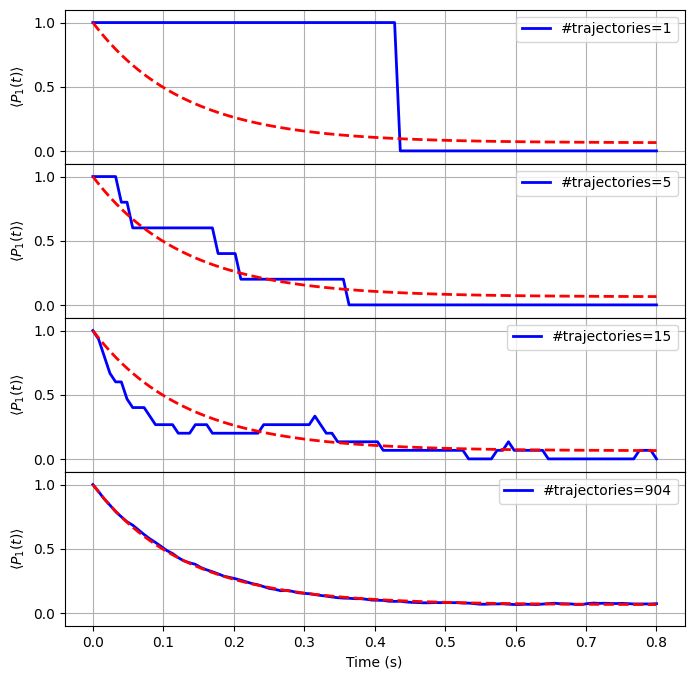

In [57]:
fig = plt.figure(figsize=(8, 8), frameon=True)
plt.subplots_adjust(hspace=0)

for i in range(len(ntraj)):
    ax = plt.subplot(4, 1, i + 1, sharex=ax if i > 0 else None)
    ax.plot(
        tlist, mc[i].expect[0], "b", lw=2,
        label="#trajectories={}".format(ntraj[i])
    )
    ax.plot(tlist, me.expect[0], "r--", lw=2)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_ylabel(r"$\langle P_{1}(t)\rangle$")
    ax.legend()
    ax.grid()
ax.set_xlabel(r"Time (s)");